# Analyse et Prédiction des Retards de Vol

Ce notebook contient toutes les étapes d'analyse exploratoire, de préparation et de modélisation sur le jeu de données des retards d'avion.

## 1. Import des librairies

In [1]:
# %pip install pandas numpy matplotlib seaborn missingno lightgbm
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import missingno as msno
%matplotlib inline

import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score
import numpy as np

## 2. Chargement des données

- Voir journal de bord pour process complet : REquiere d'avoir généré le fichier all_cleaned.parquet

In [2]:
# Chargement et aperçu du fichier nettoyé
import pandas as pd

clean_path = "data/processed/all_cleaned.parquet"
df_clean = pd.read_parquet(clean_path)

- On en profite pour faire un sample de 100 000 lignes pour faire les tests de nettoyage et d'analyse en prenant soin de garder la répartition des retards.
- Et ce sample servira pour l'entrainement pour gagner en temps d'apprentissage

In [7]:
# Échantillon stratifié de 100000 lignes selon la répartition de ARR_DEL15
df_sample = df_clean.groupby('ARR_DEL15', group_keys=False).apply(
    lambda x: x.sample(frac=100000/len(df_clean), random_state=42)
    ).reset_index(drop=True)
# on vérifie que la proportion est gardée
df_sample.head()


C:\Users\ol4\AppData\Local\Temp\ipykernel_21648\1340167087.py:2: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_sample = df_clean.groupby('ARR_DEL15', group_keys=False).apply(


,DAY_OF_WEEK,FL_DATE,UNIQUE_CARRIER,AIRLINE_ID,ORIGIN,DEST,CRS_DEP_TIME,DEP_TIME,DEP_DELAY,DEP_DEL15,TAXI_OUT,WHEELS_OFF,CRS_ARR_TIME,ARR_DEL15,CRS_ELAPSED_TIME
0,4,2016-01-28,AA,19805,MSP,DFW,500,453,-7.0,False,25.0,518,748,False,168.0
1,7,2016-10-23,OO,20304,LNK,DEN,1252,1246,-6.0,False,10.0,1256,1322,False,90.0
2,2,2016-03-15,AA,19805,CLT,BWI,1135,1132,-3.0,False,16.0,1148,1302,False,87.0
3,1,2016-03-14,F9,20436,MCO,CVG,805,802,-3.0,False,19.0,821,1017,False,132.0
4,2,2016-12-06,EV,20366,CLE,LGA,615,608,-7.0,False,29.0,637,758,False,103.0


## 3. Exploration des données

In [8]:
# Aperçu des premières lignes
df_clean.head()

,DAY_OF_WEEK,FL_DATE,UNIQUE_CARRIER,AIRLINE_ID,ORIGIN,DEST,CRS_DEP_TIME,DEP_TIME,DEP_DELAY,DEP_DEL15,TAXI_OUT,WHEELS_OFF,CRS_ARR_TIME,ARR_DEL15,CRS_ELAPSED_TIME
0,3,2016-01-06,AA,19805,DFW,DTW,1100,1057,-3.0,False,15.0,1112,1438,False,158.0
1,4,2016-01-07,AA,19805,DFW,DTW,1100,1056,-4.0,False,14.0,1110,1438,False,158.0
2,5,2016-01-08,AA,19805,DFW,DTW,1100,1055,-5.0,False,21.0,1116,1438,False,158.0
3,6,2016-01-09,AA,19805,DFW,DTW,1100,1102,2.0,False,13.0,1115,1438,False,158.0
4,7,2016-01-10,AA,19805,DFW,DTW,1100,1240,100.0,True,20.0,1300,1438,True,158.0


In [9]:
# Dimensions du dataset
df_clean.shape

(5436679, 15)

In [10]:
# Types de variables
df_clean.dtypes

DAY_OF_WEEK                  Int64
FL_DATE             datetime64[ns]
UNIQUE_CARRIER              object
AIRLINE_ID                   Int64
ORIGIN                      object
DEST                        object
CRS_DEP_TIME                 Int64
DEP_TIME                     Int64
DEP_DELAY                  float64
DEP_DEL15                  boolean
TAXI_OUT                   float64
WHEELS_OFF                   Int64
CRS_ARR_TIME                 Int64
ARR_DEL15                  boolean
CRS_ELAPSED_TIME           float64
dtype: object

In [11]:
# Statistiques descriptives
df_clean.describe(include='all')

,DAY_OF_WEEK,FL_DATE,UNIQUE_CARRIER,AIRLINE_ID,ORIGIN,DEST,CRS_DEP_TIME,DEP_TIME,DEP_DELAY,DEP_DEL15,TAXI_OUT,WHEELS_OFF,CRS_ARR_TIME,ARR_DEL15,CRS_ELAPSED_TIME
count,5436679.0,5436679,5436679,5436679.0,5436679,5436679,5436679.0,5436679.0,5.436679e+06,5436679,5.436679e+06,5436679.0,5436679.0,5436679,5.436679e+06
unique,<NA>,NaN,12,<NA>,311,310,<NA>,<NA>,NaN,2,NaN,<NA>,<NA>,2,NaN
top,<NA>,NaN,WN,<NA>,ATL,ATL,<NA>,<NA>,NaN,False,NaN,<NA>,<NA>,False,NaN
freq,<NA>,NaN,1277915,<NA>,375016,374588,<NA>,<NA>,NaN,4505013,NaN,<NA>,<NA>,4489982,NaN
mean,3.930451,2016-07-03 20:25:10.176929280,NaN,19897.112815,NaN,NaN,1330.01139,1333.458187,8.468584e+00,NaN,1.616781e+01,1355.001338,1490.365612,NaN,1.453909e+02
min,1.0,2016-01-01 00:00:00,NaN,19393.0,NaN,NaN,1.0,1.0,-5.000000e+01,NaN,1.000000e+00,1.0,1.0,NaN,1.800000e+01
25%,2.0,2016-04-04 00:00:00,NaN,19790.0,NaN,NaN,915.0,917.0,-5.000000e+00,NaN,1.100000e+01,931.0,1105.0,NaN,8.800000e+01
50%,4.0,2016-07-06 00:00:00,NaN,19805.0,NaN,NaN,1325.0,1328.0,-2.000000e+00,NaN,1.400000e+01,1340.0,1520.0,NaN,1.260000e+02
75%,6.0,2016-10-01 00:00:00,NaN,20304.0,NaN,NaN,1735.0,1742.0,6.000000e+00,NaN,1.900000e+01,1756.0,1919.0,NaN,1.780000e+02
max,7.0,2016-12-31 00:00:00,NaN,21171.0,NaN,NaN,2359.0,2400.0,5.000000e+02,NaN,1.860000e+02,2400.0,2400.0,NaN,7.050000e+02


In [12]:
# Vérification des valeurs manquantes
df_clean.isnull().sum() if df_clean is not None else 'Données non chargées'

DAY_OF_WEEK         0
FL_DATE             0
UNIQUE_CARRIER      0
AIRLINE_ID          0
ORIGIN              0
DEST                0
CRS_DEP_TIME        0
DEP_TIME            0
DEP_DELAY           0
DEP_DEL15           0
TAXI_OUT            0
WHEELS_OFF          0
CRS_ARR_TIME        0
ARR_DEL15           0
CRS_ELAPSED_TIME    0
dtype: int64

## 4. Visualisations

<Axes: >

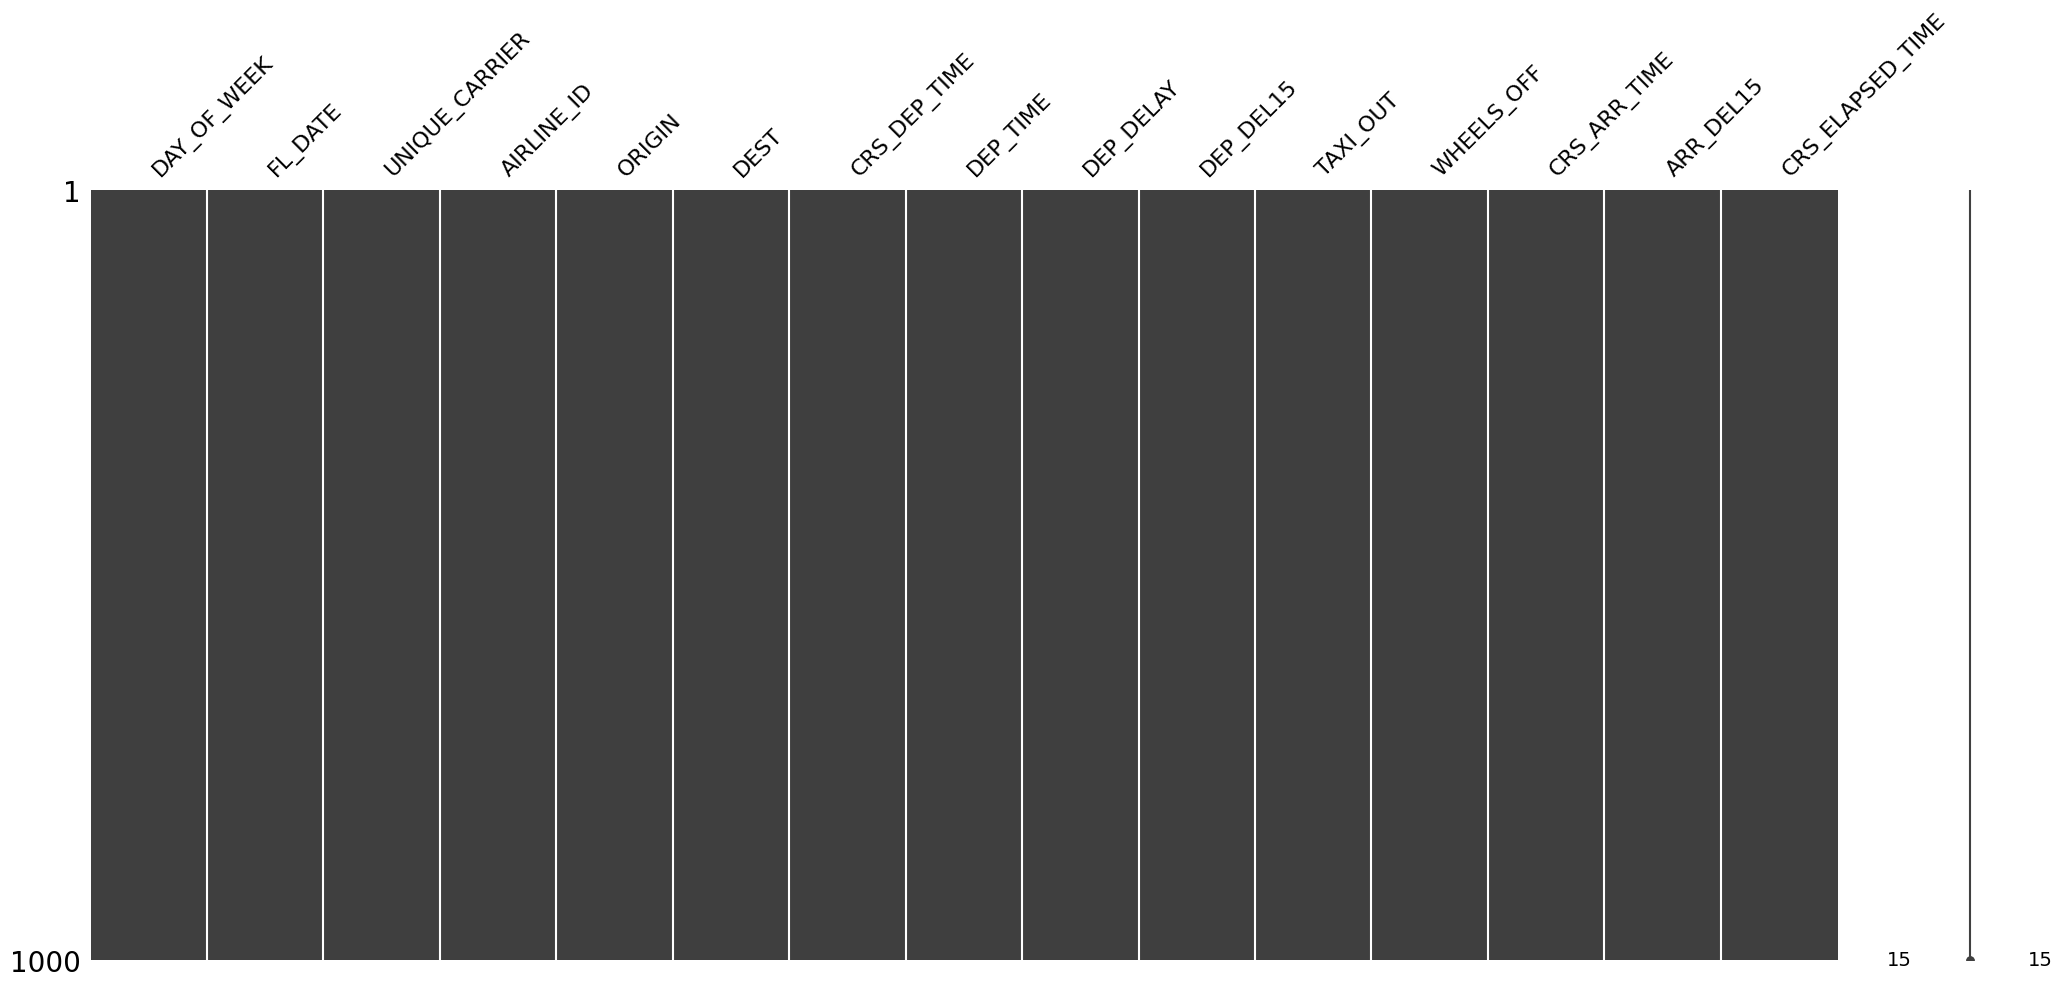

In [13]:
msno.matrix(df_clean.sample(1000))

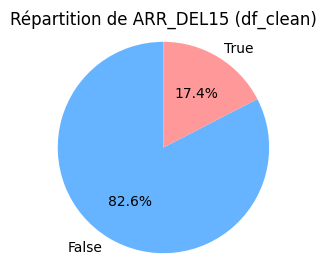

In [14]:
# Visualisation camembert de la répartition de ARR_DEL15 sur df_clean


arr_del15_counts = df_clean['ARR_DEL15'].value_counts(dropna=False)
labels = arr_del15_counts.index.astype(str)
plt.figure(figsize=(3, 3))
plt.pie(arr_del15_counts, labels=labels, autopct='%1.1f%%', startangle=90, colors=['#66b3ff','#ff9999','#99ff99','#ffcc99'])
plt.title('Répartition de ARR_DEL15 (df_clean)')
plt.axis('equal')
plt.show()

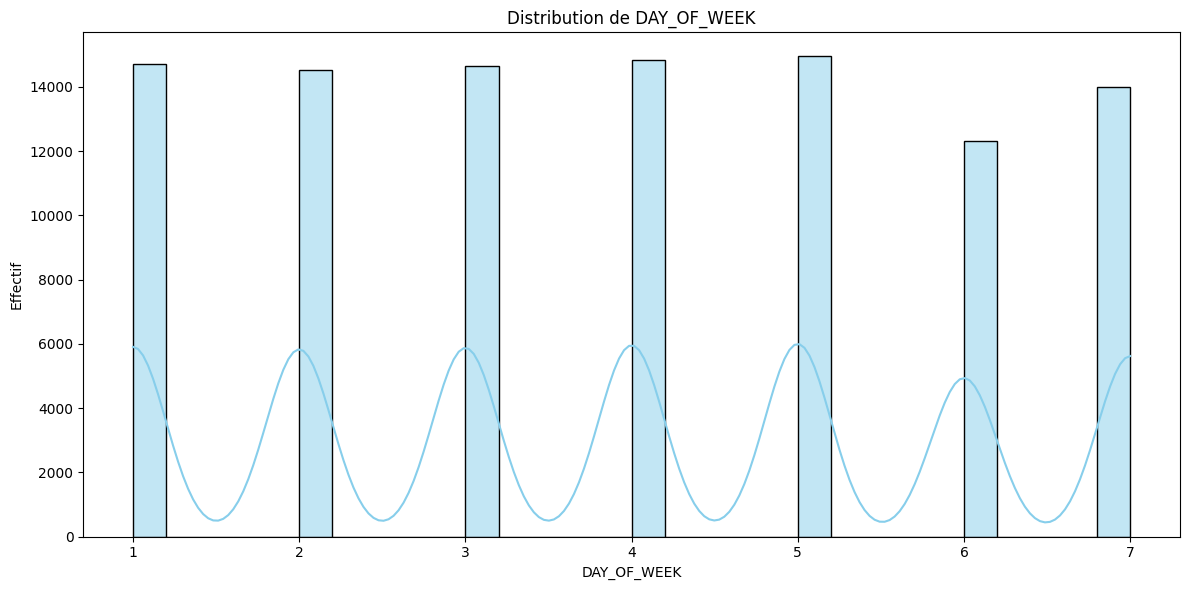

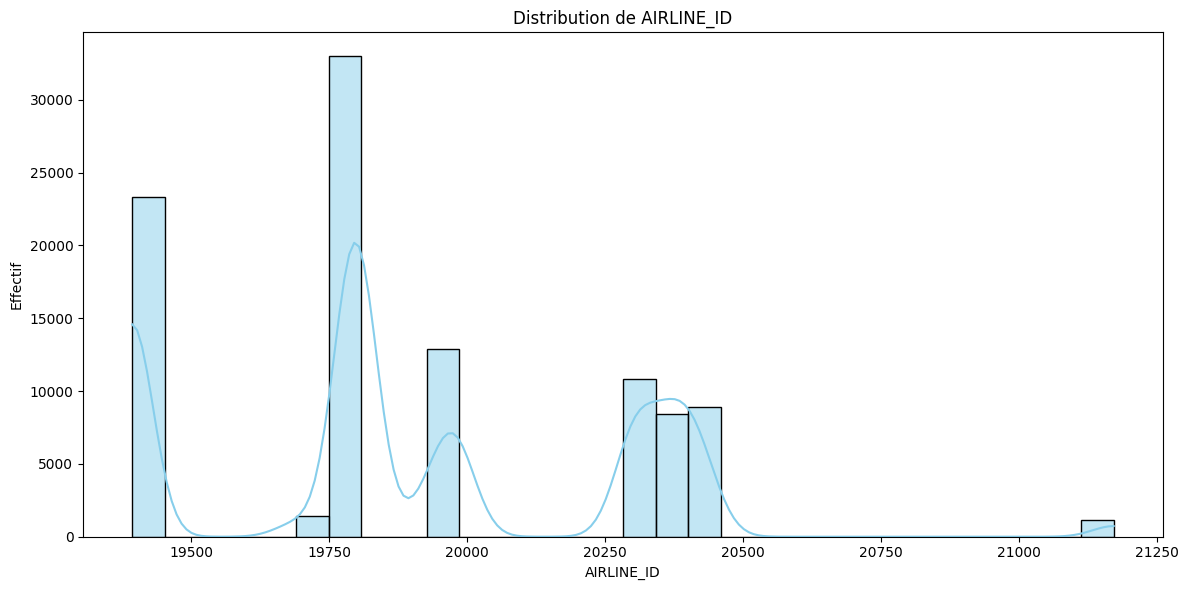

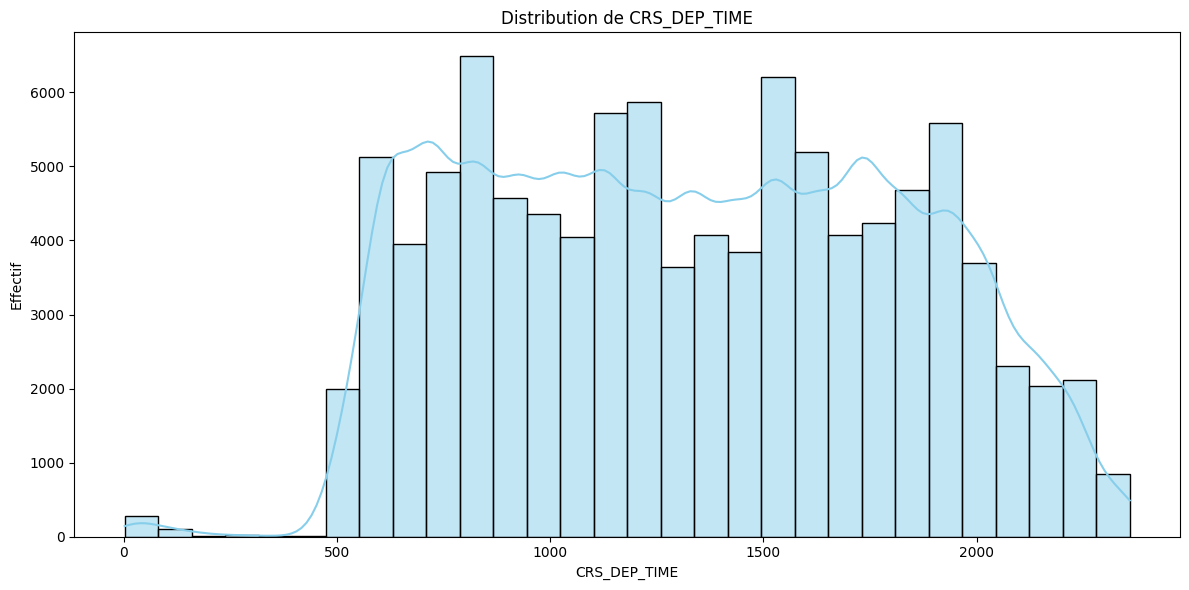

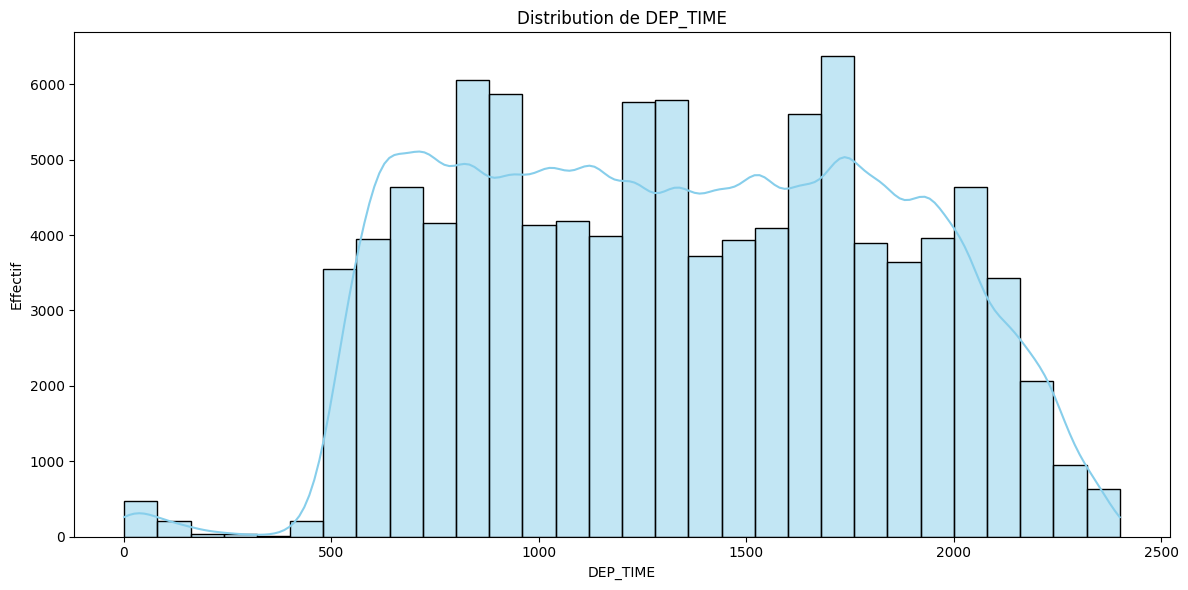

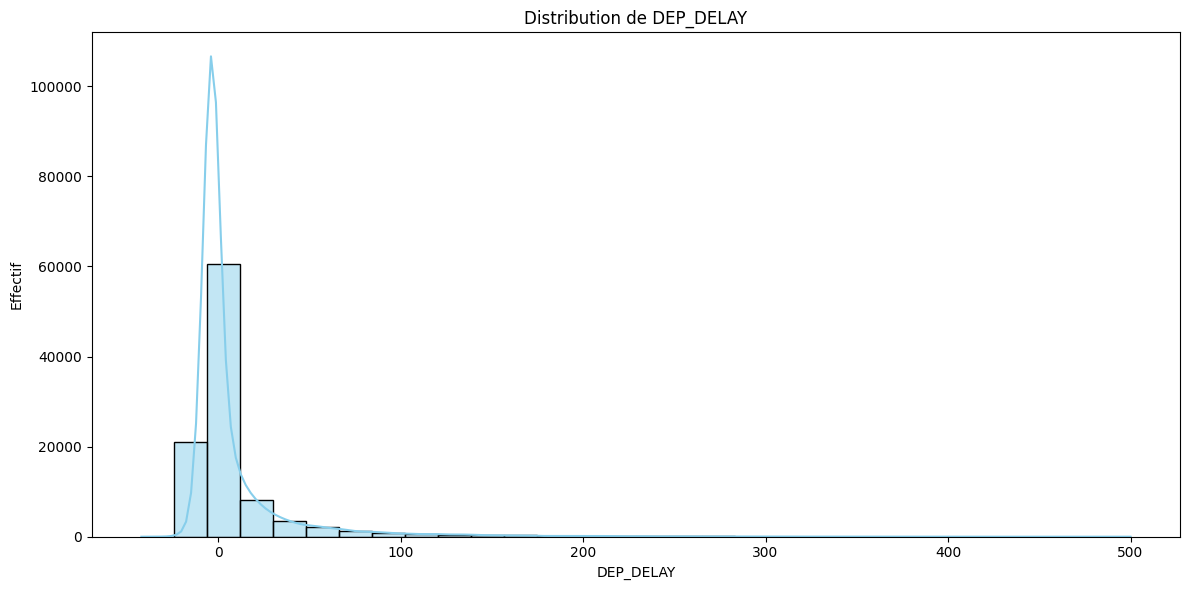

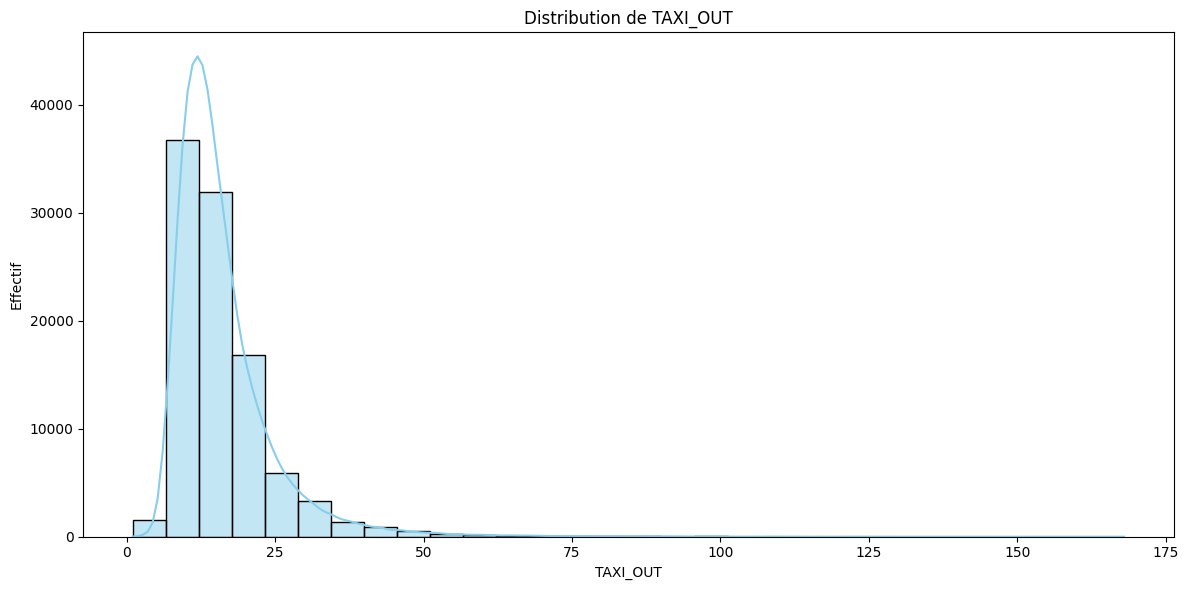

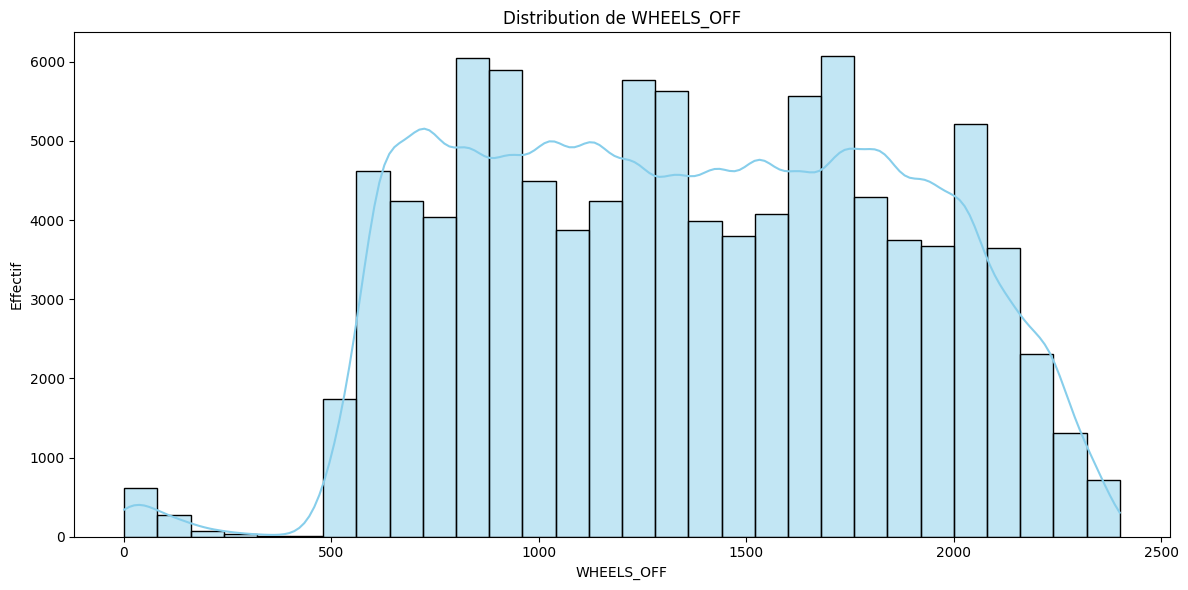

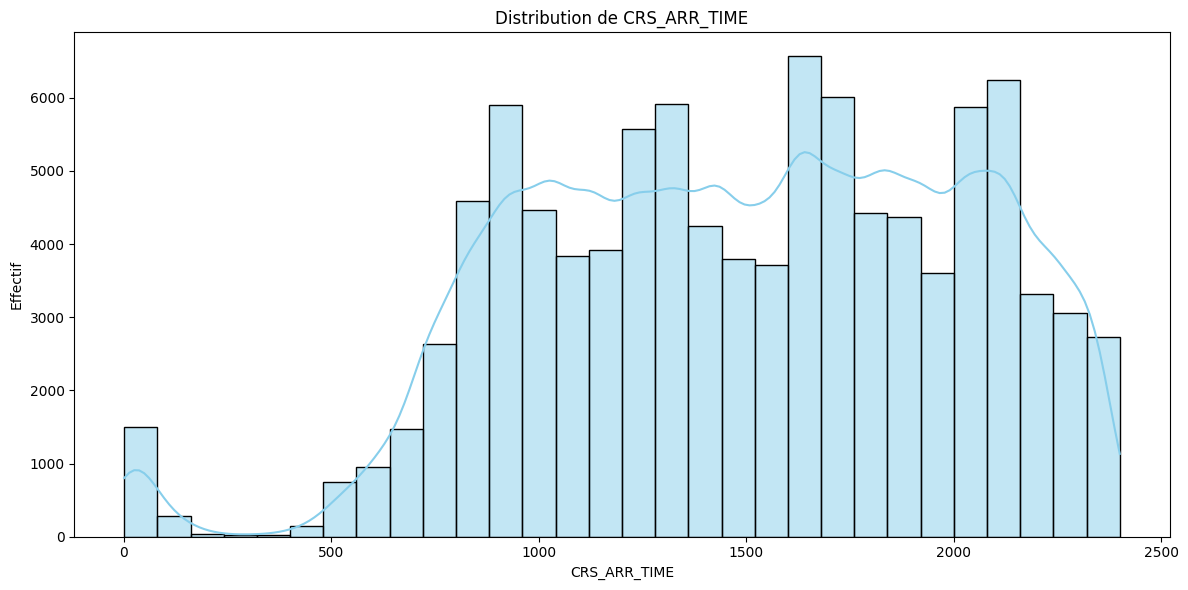

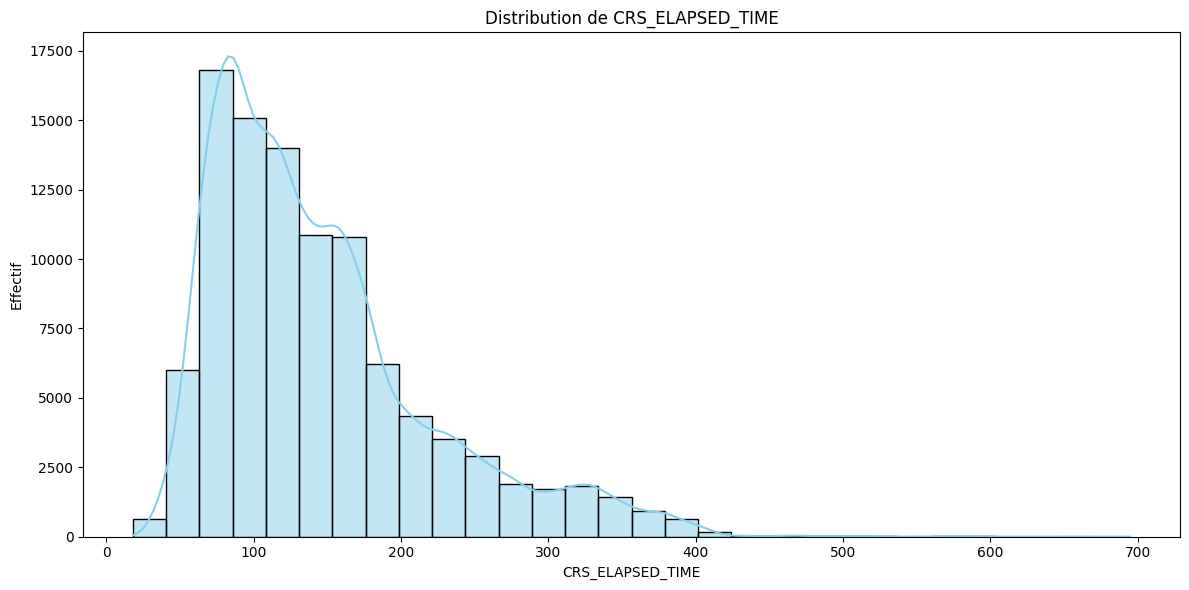

In [15]:
# Analyse des outliers sur les colonnes numériques
import matplotlib.pyplot as plt
import seaborn as sns
num_cols = df_clean.select_dtypes(include=['int64', 'float64']).columns

# Visualisation des distributions
for col in num_cols:
    plt.figure(figsize=(12, 6))
    sns.histplot(df_sample[col].dropna(), bins=30, kde=True, color='skyblue')
    plt.title(f"Distribution de {col}")
    plt.xlabel(col)
    plt.ylabel("Effectif")
    plt.tight_layout()
    plt.show()

## 5. Modélisation

In [16]:
# Modélisation : LightGBMClassifier sur df_clean (cible ARR_DEL15)


sample_train = df_sample.copy()

# Conversion du datetime en timestamp pour garder une information temporelle
sample_train["FL_DATE"] = sample_train["FL_DATE"].astype("int64") // 10**9  # en secondes

# test context : 
sample_train = sample_train.sample(n=10000, random_state=42)

# Préparation des données : X = toutes les colonnes sauf ARR_DEL15, y = ARR_DEL15
y = sample_train['ARR_DEL15'].astype(int)
X = sample_train.drop(columns=['ARR_DEL15'])

# Encodage des variables catégorielles (one-hot)
X = pd.get_dummies(X, drop_first=True)

# Split train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Standardisation des features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Entraînement du modèle LightGBM
lgb_clf = lgb.LGBMClassifier(random_state=42, n_estimators=100)
lgb_clf.fit(X_train_scaled, y_train)

# Prédiction des probabilités
lgb_pred_prob = lgb_clf.predict_proba(X_test_scaled)

# Score AUC
lgb_auc_score = roc_auc_score(y_test, lgb_pred_prob[:,1])
print(f"AUC score (LightGBM) : {lgb_auc_score:.4f}")

[LightGBM] [Info] Number of positive: 1210, number of negative: 5790
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.005744 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2187
[LightGBM] [Info] Number of data points in the train set: 7000, number of used features: 148
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.172857 -> initscore=-1.565512
[LightGBM] [Info] Start training from score -1.565512
AUC score (LightGBM) : 0.9643


e:\01_WORKS\00_wip\7SHAPES\simplon\mod6_1\.venv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
